# Identify Retrieval Heads Using Sum Attention Method

### Retrieval Head Identification Using Sum Attention Method

In [1]:
%pip install torch transformers numpy huggingface_hub accelerate bitsandbytes dotenv pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.8 MB/s eta 0:00:00


In [2]:
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import accelerate
from huggingface_hub import login
from dotenv import load_dotenv
import json
from datetime import datetime

#### If using Google Colab: Run The Following Cells (Ignore if using some other environment)

In [3]:
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')

In [4]:
if HF_TOKEN:
    login(token=HF_TOKEN)
    print("HF_TOKEN loaded and Hugging Face login successful.")
else:
    print("HF_TOKEN not found.")

HF_TOKEN loaded and Hugging Face login successful.


#### If using a high end GPU not from Colab, but from Lambda Labs

In [ ]:
# Load HF_TOKEN from a local .env file (works in Lambda Labs / venv / local runs)
load_dotenv(override=False)

# Prefer token from .env or environment; fall back to an existing HF_TOKEN variable (e.g., Colab cell)
HF_TOKEN = os.getenv("HF_TOKEN") or globals().get("HF_TOKEN")

if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    login(token=HF_TOKEN)
    print("HF_TOKEN loaded and Hugging Face login successful.")
else:
    print("HF_TOKEN not found. Add HF_TOKEN=... to your .env file or set it in the environment.")

#### Configuration & Hyperparameters

In [5]:
import torch

# Model
MODEL_ID = "meta-llama/Meta-Llama-3-8B-Instruct"

# Data and Needle Stuff

TARGET_SEQ_LEN = 7000

NEEDLE_DEPTH = 0.5
SPLIT = 0.8

# No magic numbers, for reproduction
SPLIT_SEED = 42
TOP_K_HEADS = 20

TASKS = [
    {"id": "registrant_name", "question": "What is the registrant's name?"},
    {"id": "headquarters_city", "question": "What is the registrant's headquarters city?"},
    {"id": "headquarters_state", "question": "What is the registrant's headquarters state?"},
    # incorporation state and year should (would it be better to ask for the current state and year instead?)
    {"id": "incorporation_state", "question": "What is the registrant's incorporation state?"},
    {"id": "incorporation_year", "question": "What is the incorporation year?"},

    {"id": "employees_count_total", "question": "How many total employees does the registrant have?"},
    {"id": "holder_record_amount", "question": "What is the number of holders of record of the registrant's common stock?"},
    {"id": "employees_count_full_time", "question": "How many full-time employees does the registrant have?"},
    {"id": "ceo_lastname", "question": "What is the CEO's last name?"},
]

TASK_MAP = {t["id"]: t for t in TASKS}

# Paths
DATA_PATH = "/content/cleaned_EDGAR_gt_2-22-2026.csv"

# Set up output directories
TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
RUN_NAME = f"llama3-8B_instruct_run_{TIMESTAMP}"
BASE_OUTPUT_DIR = f"content/data/retrieval_heads/{RUN_NAME}"
RAW_OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, "raw")
RESULTS_OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, "results")

# Model Loading Options
TORCH_DTYPE = torch.bfloat16
ATTN_IMPL = "eager"

# Formatted by AI to see configs and all that
print("Configuration loaded.")
print(f"Model: {MODEL_ID}")
print(f"Seq length : {TARGET_SEQ_LEN} tokens")
print(f"Needle depth : {NEEDLE_DEPTH * 100:.0f}%")
print(f"ID split: {SPLIT * 100:.0f}% (seed={SPLIT_SEED})")
print(f"Top-K heads: {TOP_K_HEADS}")
print(f"Tasks: {len(TASKS)}")
print(f"dtype: {TORCH_DTYPE}")
print(f"attn_impl: {ATTN_IMPL}")

Configuration loaded.
Model: meta-llama/Meta-Llama-3-8B-Instruct
Seq length : 7000 tokens
Needle depth : 50%
ID split: 80% (seed=42)
Top-K heads: 20
Tasks: 9
dtype: torch.bfloat16
attn_impl: eager



##### Tokenizer & Model Loading

In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Tokenizer loaded: {MODEL_ID}")
print(f"Vocab size: {tokenizer.vocab_size:,}")
print(f"Model max length: {tokenizer.model_max_length:,}")
print(f"Pad token: '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

Tokenizer loaded: meta-llama/Meta-Llama-3-8B-Instruct
Vocab size: 128,000
Model max length: 1,000,000,000,000,000,019,884,624,838,656
Pad token: '<|eot_id|>' (id=128009)


In [7]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    token=HF_TOKEN,
    torch_dtype=TORCH_DTYPE,
    device_map="auto",
    attn_implementation=ATTN_IMPL,
)
model.eval()

# Formatted by AI to see configs and all that
print(f"Model loaded: {MODEL_ID}")
print(f"dtype: {next(model.parameters()).dtype}")
print(f"Num layers: {model.config.num_hidden_layers}")
print(f"Num heads (Q): {model.config.num_attention_heads}")
print(f"Num KV heads: {model.config.num_key_value_heads}")
print(f"Total heads: {model.config.num_hidden_layers * model.config.num_attention_heads:,}")


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Model loaded: meta-llama/Meta-Llama-3-8B-Instruct
dtype: torch.bfloat16
Num layers: 32
Num heads (Q): 32
Num KV heads: 8
Total heads: 1,024


#### Set up Dataset and splitting and all that jazz

In [8]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(DATA_PATH)


In [9]:
identification_df, ablation_df = train_test_split(
    df,
    test_size=1 - SPLIT,
    stratify=df["task"],
    random_state=SPLIT_SEED,
)

identification_df = identification_df.reset_index(drop=True)
ablation_df = ablation_df.reset_index(drop=True)

# Asked by AI
print(f"Identification set : {len(identification_df):,} samples ({len(identification_df)/len(df):.0%})")
print(f"Ablation set : {len(ablation_df):,} samples ({len(ablation_df)/len(df):.0%})")


Identification set : 1,061 samples (80%)
Ablation set : 266 samples (20%)


In [10]:
counts = pd.DataFrame({
    "total": df.groupby("task").size(),
    "identification": identification_df.groupby("task").size(),
    "ablation": ablation_df.groupby("task").size(),
})
counts["id_%"] = (counts["identification"] / counts["total"] * 100).round(1)
counts["abl_%"] = (counts["ablation"] / counts["total"] * 100).round(1)

print(counts.to_string())


                           total  identification  ablation  id_%  abl_%
task                                                                   
ceo_lastname                 171             137        34  80.1   19.9
employees_count_full_time     49              39        10  79.6   20.4
employees_count_total        147             118        29  80.3   19.7
headquarters_city            144             115        29  79.9   20.1
headquarters_state           139             111        28  79.9   20.1
holder_record_amount         147             118        29  80.3   19.7
incorporation_state          158             126        32  79.7   20.3
incorporation_year           159             127        32  79.9   20.1
registrant_name              213             170        43  79.8   20.2


#### Building Prompt

In [11]:
def find_needle_span(
    prompt_ids: list[int],
    needle_ids: list[int],
    threshold: float = 0.9,
) -> tuple[int, int]:
    """Locate needle tokens inside the full tokenized prompt via sliding window overlap."""
    span_len = len(needle_ids)
    if span_len == 0:
        return -1, -1

    needle_set = set(needle_ids)

    for i in range(len(prompt_ids) - span_len + 1):
        window = set(prompt_ids[i : i + span_len])
        if len(window & needle_set) / len(needle_set) >= threshold:
            return i, i + span_len

    return -1, -1


In [12]:
import re

# It is only <|begin_of_text|> that seems to exist, but I removed all control tokens just to be safe.
CONTROL_TOKENS = ["<|begin_of_text|>", "<|end_of_text|>", "<|eot_id|>", "<|start_header_id|>", "<|end_header_id|>"]
TOKEN_PATTERN = re.compile("|".join(re.escape(t) for t in CONTROL_TOKENS))

def build_prompt(row: pd.Series, task: dict, tokenizer) -> dict:
    """Construct the full prompt with the needle sentence inserted, and locate the needle span in the tokenized input."""

    haystack = TOKEN_PATTERN.sub("", row["haystack_text"]).strip()
    needle = row["needle_sentence"]


    mid = len(haystack) // 2
    context = haystack[:mid] + " " + needle + " " + haystack[mid:]

    message = f"<document>{context}</document>\nQuestion: {task['question']}\nAnswer:"
    messages = [{"role": "user", "content": message}]

    encoded = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    input_ids = encoded["input_ids"]

    # Locate needle span in the tokenized prompt
    needle_ids = tokenizer.encode(needle, add_special_tokens=False)
    needle_start, needle_end = find_needle_span(input_ids[0].tolist(), needle_ids)

    return {
        "input_ids": input_ids,
        "needle_ids": needle_ids,
        "needle_start": needle_start,
        "needle_end": needle_end,
    }


#### Just some validation of the prompt building logic

In [13]:
import random
for i in range(5):
    random_number = random.randint(0, len(identification_df) - 1)
    sample_row = identification_df.iloc[random_number]
    sample_task = TASK_MAP[sample_row["task"]]
    result = build_prompt(sample_row, sample_task, tokenizer)

    print(f"input_ids shape: {result['input_ids'].shape}")
    print(f"needle_start: {result['needle_start']}")
    print(f"needle_end: {result['needle_end']}")
    print(f"needle span len: {result['needle_end'] - result['needle_start']} tokens")
    print(f"total tokens: {result['input_ids'].shape[1]}")
    print()

    decoded = tokenizer.decode(result["input_ids"][0, result["needle_start"]:result["needle_end"]])
    print(f"decoded needle:\n{decoded}")
    print(f"\noriginal needle:\n{sample_row['needle_sentence']}")


input_ids shape: torch.Size([1, 7051])
needle_start: 3670
needle_end: 3693
needle span len: 23 tokens
total tokens: 7051

decoded needle:
 mar Honeywell employed approximately 52,300 persons in total operations as of December 31, 1993.

original needle:
Honeywell employed approximately 52,300 persons in total operations as of December 31, 1993.
input_ids shape: torch.Size([1, 7063])
needle_start: 3435
needle_end: 3476
needle span len: 41 tokens
total tokens: 7063

decoded needle:
 be adj Maxicare Health Plans, Inc., a Delaware corporation (the "Company") is a managed health care company, with a combined enrollment of approximately 293,000 at January 1, 199

original needle:
Maxicare Health Plans, Inc., a Delaware corporation (the "Company") is a managed health care company, with a combined enrollment of approximately 293,000 at January 1, 1994.
input_ids shape: torch.Size([1, 7035])
needle_start: 3492
needle_end: 3523
needle span len: 31 tokens
total tokens: 7035

decoded needle:
iz Th

#### Run Model & Extract the Attention Weights

In [14]:
def compute_sum_attn(model, prompt_inputs:dict) -> np.ndarray:
    """
    Compute the summed attention scores for each head across all layers, given the prompt inputs.
    """

    # Just make this a bit more cleaner and easier to read
    input_ids = prompt_inputs["input_ids"].to(model.device)
    needle_start = prompt_inputs["needle_start"]
    needle_end = prompt_inputs["needle_end"]

    with torch.inference_mode():
        prefill = model(
            input_ids=input_ids[:, :-1],
            use_cache=True,
            output_attentions=False,
            return_dict=True,
        )

        decode = model(
            input_ids=input_ids[:, -1:],
            past_key_values=prefill.past_key_values,
            use_cache=False,
            output_attentions=True,
            return_dict=True,
        )

    num_layers = model.config.num_hidden_layers
    num_heads = model.config.num_attention_heads
    scores = np.zeros((num_layers, num_heads), dtype=np.float32)

    for layer_idx, layer_attn in enumerate(decode.attentions):
        attn = layer_attn[0, :, 0, :].float().cpu().numpy()

        # scores[layer_idx] = attn[:, needle_start:needle_end].mean(axis=1)
        # we could use mean instead of sum to normalize
        # for different needle lengths
        scores[layer_idx] = attn[:, needle_start:needle_end].sum(axis=1)

    return scores

Go grab scores for every task

In [16]:
os.makedirs(RAW_OUTPUT_DIR, exist_ok=True)

skipped = 0
total = len(identification_df)

for index, row in identification_df.iterrows():
    if pd.isna(row["haystack_text"]) or pd.isna(row["needle_sentence"]):
        print(f"[{index}/{total}] SKIP — missing text data ({row['filename']})")
        skipped += 1
        continue

    task = TASK_MAP[row["task"]]

    filename = f"{row['filename'].replace('.txt', '')}_{task['id']}.npy"
    file_path = os.path.join(RAW_OUTPUT_DIR, filename)

    if os.path.exists(file_path):
        print(f"[{index}/{total}] SKIP - already processed {filename}")
        continue

    # 3. Normal processing
    prompt = build_prompt(row, task, tokenizer)

    if prompt["needle_start"] == -1:
        print(f"[{index}/{total}] SKIP - needle not found ({row['filename']})")
        skipped += 1
        continue

    scores = compute_sum_attn(model, prompt)
    np.save(file_path, scores)

    print(f"[{index}/{total}] saved {filename}")

    del prompt, scores
    torch.cuda.empty_cache()

print(f"\nDone. {total - skipped}/{total} saved, {skipped} skipped.")

[0/1061] SKIP - already processed 745287_1993_employees_count_total.npy
[1/1061] SKIP - needle not found (1800_1993.txt)
[2/1061] SKIP - already processed 79166_1993_holder_record_amount.npy
[3/1061] SKIP - already processed 105418_1993_incorporation_year.npy
[4/1061] SKIP - already processed 722079_1993_incorporation_year.npy
[5/1061] SKIP - already processed 732714_1993_headquarters_city.npy
[6/1061] SKIP - already processed 277821_1993_headquarters_state.npy
[7/1061] SKIP - already processed 46207_1993_ceo_lastname.npy
[8/1061] SKIP - already processed 64803_1993_ceo_lastname.npy
[9/1061] SKIP - already processed 717605_1993_ceo_lastname.npy
[10/1061] SKIP - already processed 36966_1993_employees_count_full_time.npy
[11/1061] SKIP - already processed 714655_1993_ceo_lastname.npy
[12/1061] SKIP - already processed 859119_1993_incorporation_state.npy
[13/1061] SKIP - already processed 103730_1993_incorporation_year.npy
[14/1061] SKIP - already processed 51296_1993_headquarters_city.np

#### Get mean scores across tasks and identify top heads

In [17]:
task_mean_scores = {}

for task_id in TASK_MAP:
    files = [f for f in os.listdir(RAW_OUTPUT_DIR) if f.endswith(f"_{task_id}.npy")]
    if not files:
        print(f"WARNING: no files found for task '{task_id}' — skipping")
        continue
    stacked = np.stack([np.load(os.path.join(RAW_OUTPUT_DIR, f)) for f in files])
    task_mean_scores[task_id] = stacked.mean(axis=0)
    print(f"{task_id:<35} {len(files):>4} samples -> mean shape {task_mean_scores[task_id].shape}")

print(f"\n{len(task_mean_scores)} tasks aggregated.")

registrant_name                      156 samples -> mean shape (32, 32)
headquarters_city                    110 samples -> mean shape (32, 32)
headquarters_state                   107 samples -> mean shape (32, 32)
incorporation_state                  120 samples -> mean shape (32, 32)
incorporation_year                   123 samples -> mean shape (32, 32)
employees_count_total                114 samples -> mean shape (32, 32)
holder_record_amount                 118 samples -> mean shape (32, 32)
employees_count_full_time             36 samples -> mean shape (32, 32)
ceo_lastname                         131 samples -> mean shape (32, 32)

9 tasks aggregated.


#### Ranking top-k heads

In [18]:
os.makedirs(RESULTS_OUTPUT_DIR, exist_ok=True)

##### General top-k heads

In [19]:
task_top_heads = {}

for task_id, mean_scores in task_mean_scores.items():
    flat = mean_scores.flatten()
    top_flat = np.argsort(flat)[::-1][:TOP_K_HEADS]

    num_heads = mean_scores.shape[1]
    heads = [
        {
            "layer": int(idx // num_heads),
            "head": int(idx % num_heads),
            "score": float(flat[idx]),
        }
        for idx in top_flat
    ]

    task_top_heads[task_id] = heads

#### Cross-task shared heads (intersection)

In [20]:
from collections import Counter

# Instead of dealing with the inserection with ALL tasks, I decided
# that it would make more sense that given, hey this head intersects
# with 7 or more tasks, I think it could be considered a "general"
# retrieval head

all_top_heads = []
for heads in task_top_heads.values():
    all_top_heads.extend([(h["layer"], h["head"]) for h in heads])

In [21]:
head_counts = Counter(all_top_heads)
MIN_TASKS = 7
shared_head_pairs = [head for head, count in head_counts.items() if count >= MIN_TASKS]


In [22]:
shared_heads = []
for layer, head in shared_head_pairs:
    freq = head_counts[(layer, head)]
    avg_score = float(np.mean([
        task_mean_scores[tid][layer, head]
        for tid in task_mean_scores
    ]))

    shared_heads.append({
        "layer": layer,
        "head": head,
        "avg_score": avg_score,
        "task_frequency": freq
    })

shared_heads.sort(key=lambda x: (x["task_frequency"], x["avg_score"]), reverse=True)

#### Exporting/Saving

In [23]:
output = {
    "model": MODEL_ID,
    "top_k": TOP_K_HEADS,
    "tasks": task_top_heads,
    "shared_heads": shared_heads,
}
out_path = os.path.join(RESULTS_OUTPUT_DIR, "retrieval_heads.json")

with open(out_path, "w") as f:
    json.dump(output, f, indent=2)

print(f"Saved at: {out_path}")
print(
    f"\nShared retrieval heads across all {len(task_mean_scores)} tasks ({len(shared_heads)} found):"
)

for h in shared_heads:
    print(
        f"Layer {h['layer']:>2}     Head {h['head']:>2}     avg_score={h['avg_score']:.4f}"
    )

Saved at: content/data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50/results/retrieval_heads.json

Shared retrieval heads across all 9 tasks (7 found):
Layer 17     Head 24     avg_score=0.3200
Layer 22     Head 15     avg_score=0.1161
Layer 22     Head 12     avg_score=0.1099
Layer 20     Head 25     avg_score=0.1236
Layer 22     Head 14     avg_score=0.1120
Layer 20     Head 14     avg_score=0.1101
Layer 22     Head 13     avg_score=0.1018


#### Plotting

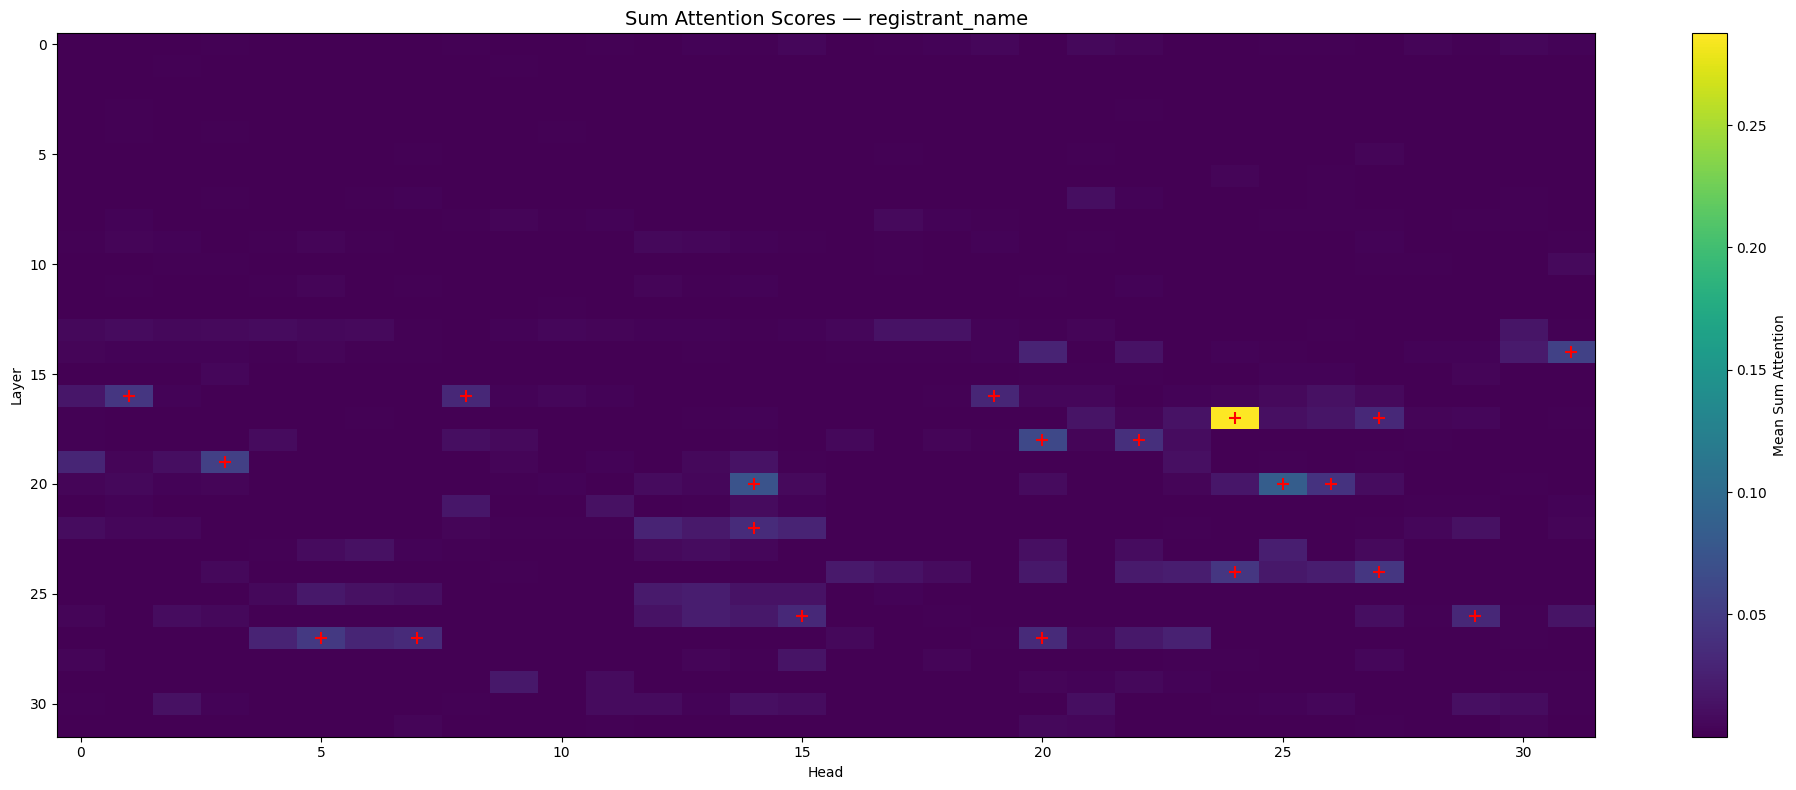

Saved at: content/data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50/results/heatmap_registrant_name.png


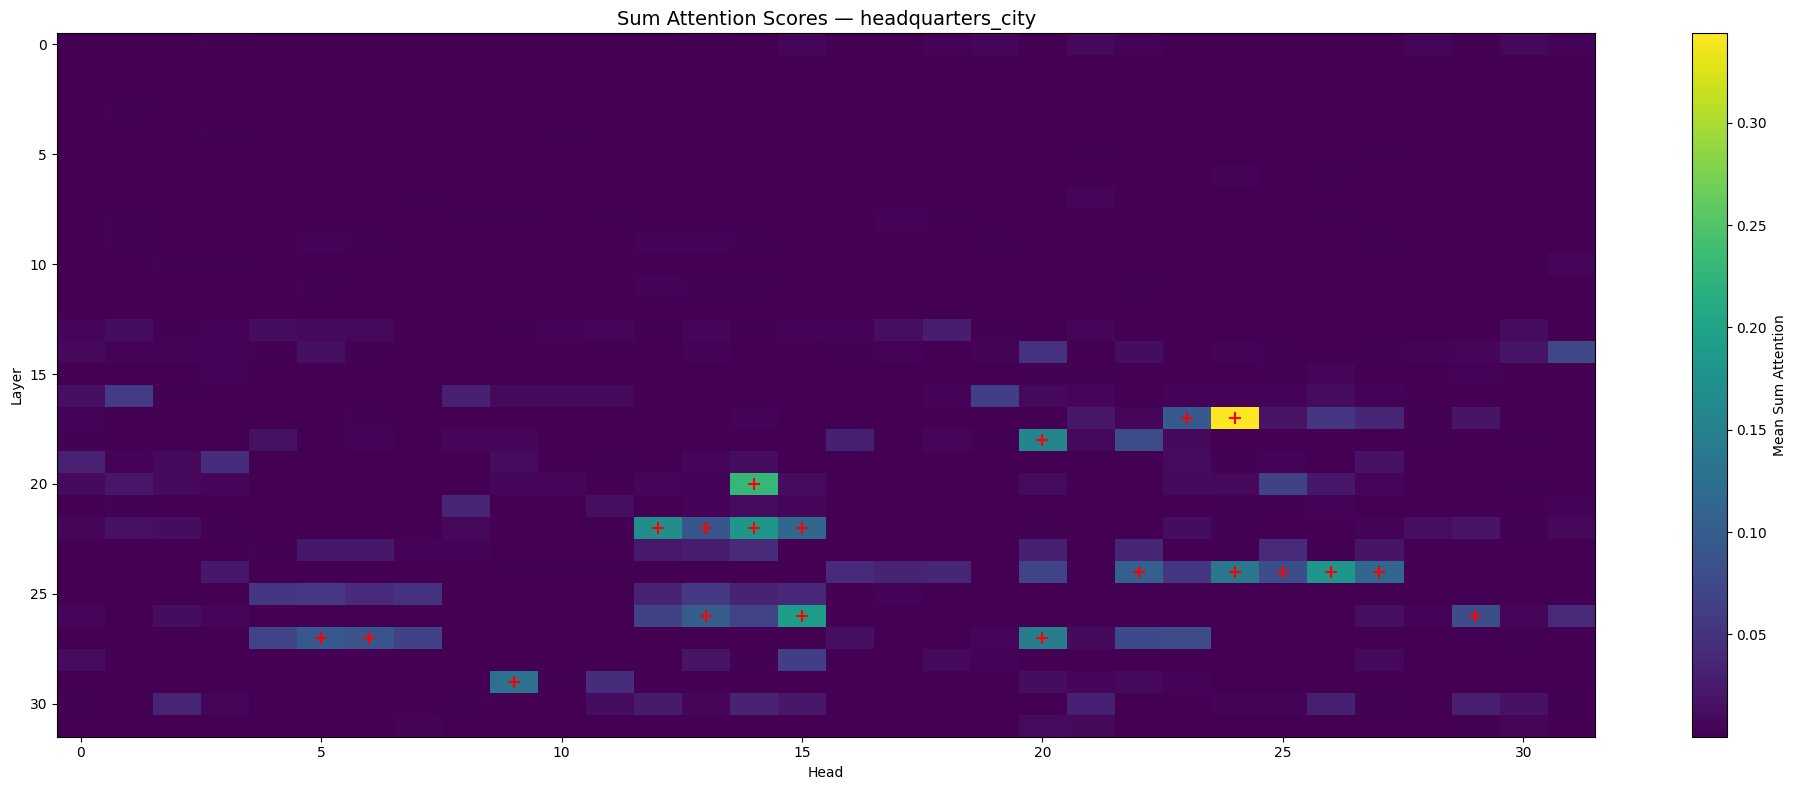

Saved at: content/data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50/results/heatmap_headquarters_city.png


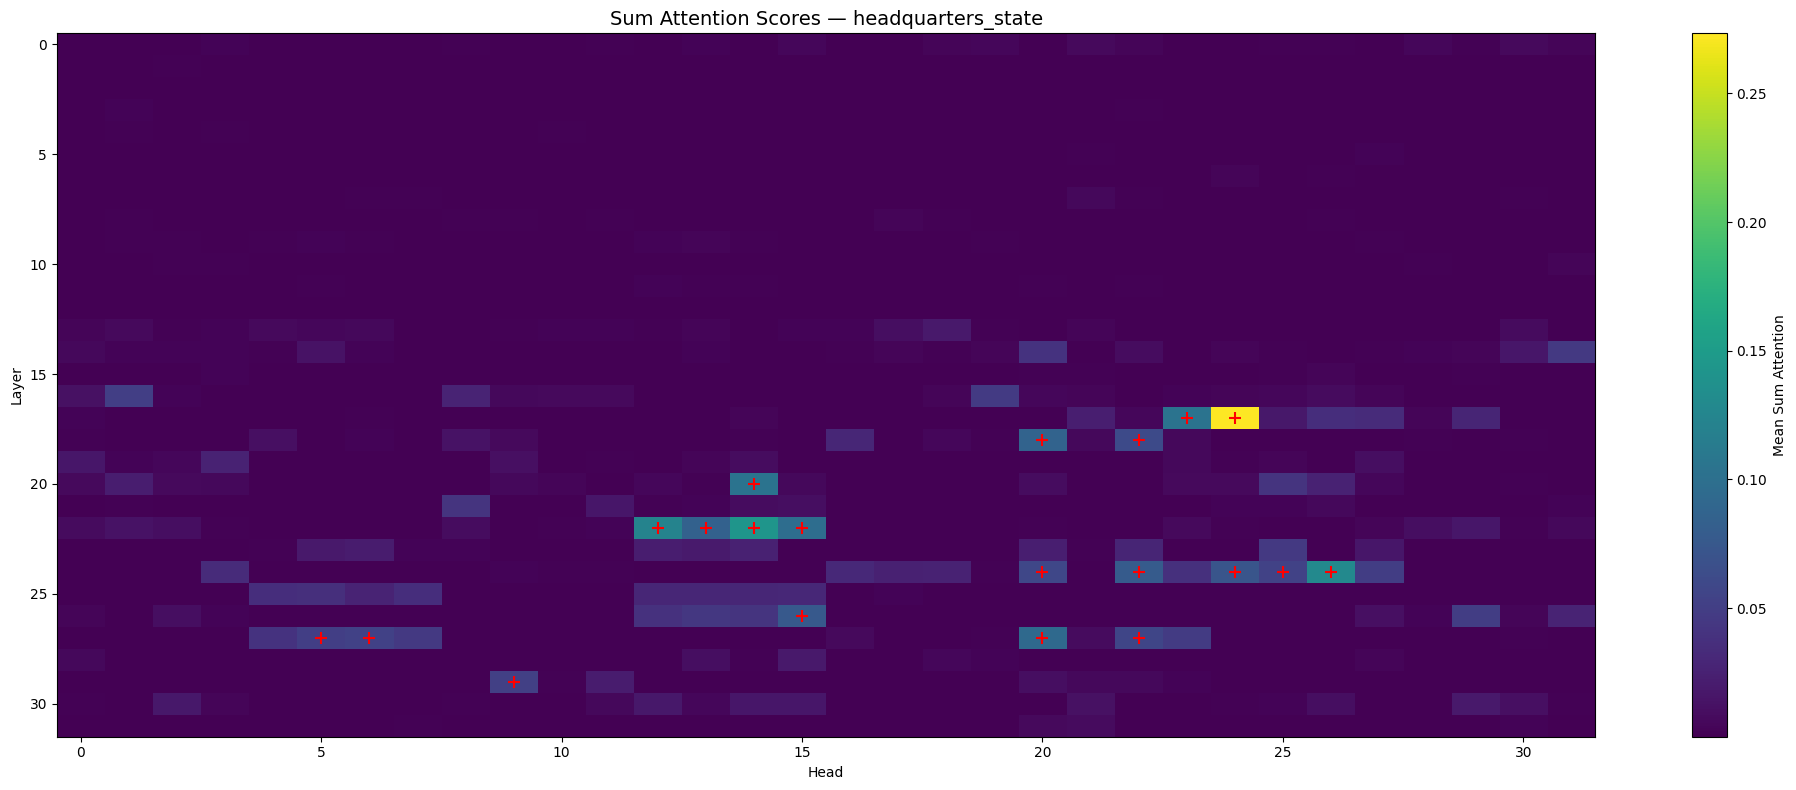

Saved at: content/data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50/results/heatmap_headquarters_state.png


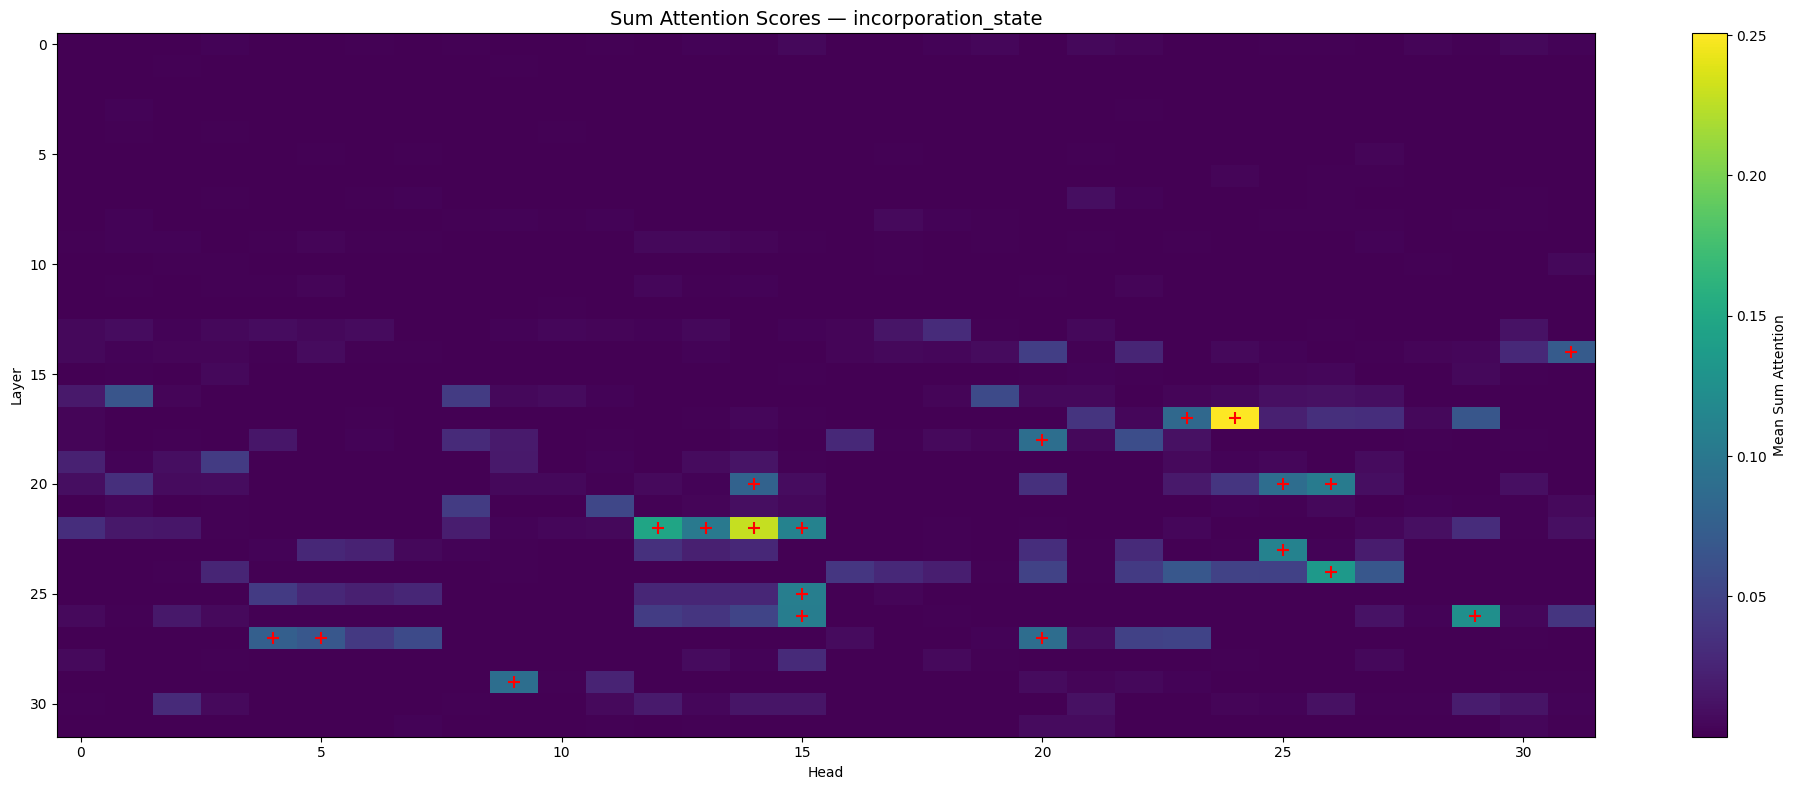

Saved at: content/data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50/results/heatmap_incorporation_state.png


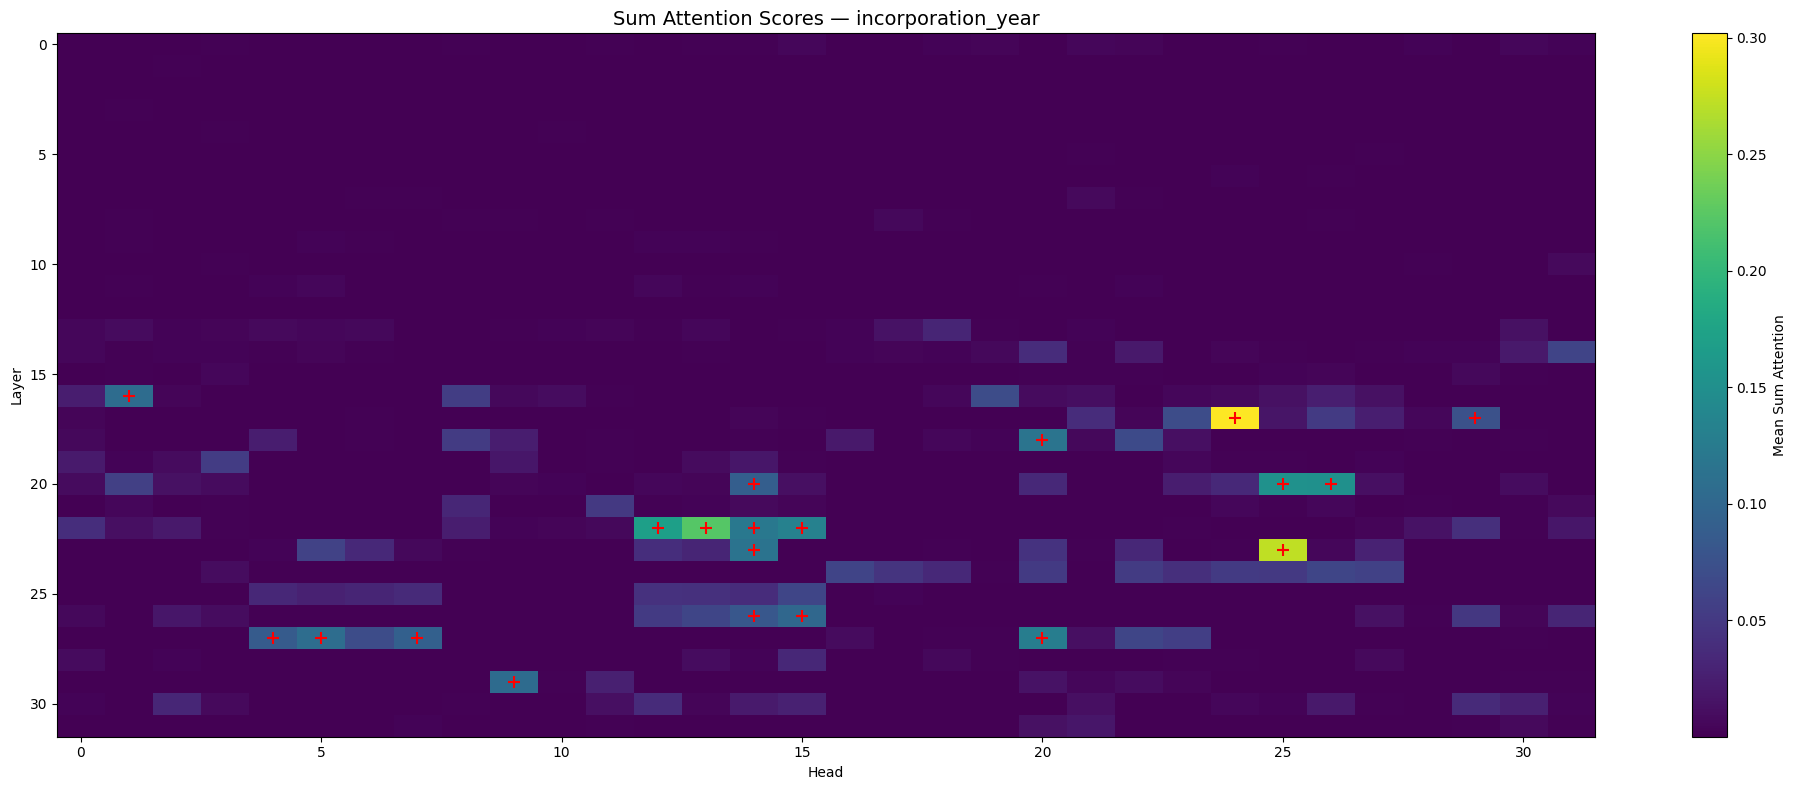

Saved at: content/data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50/results/heatmap_incorporation_year.png


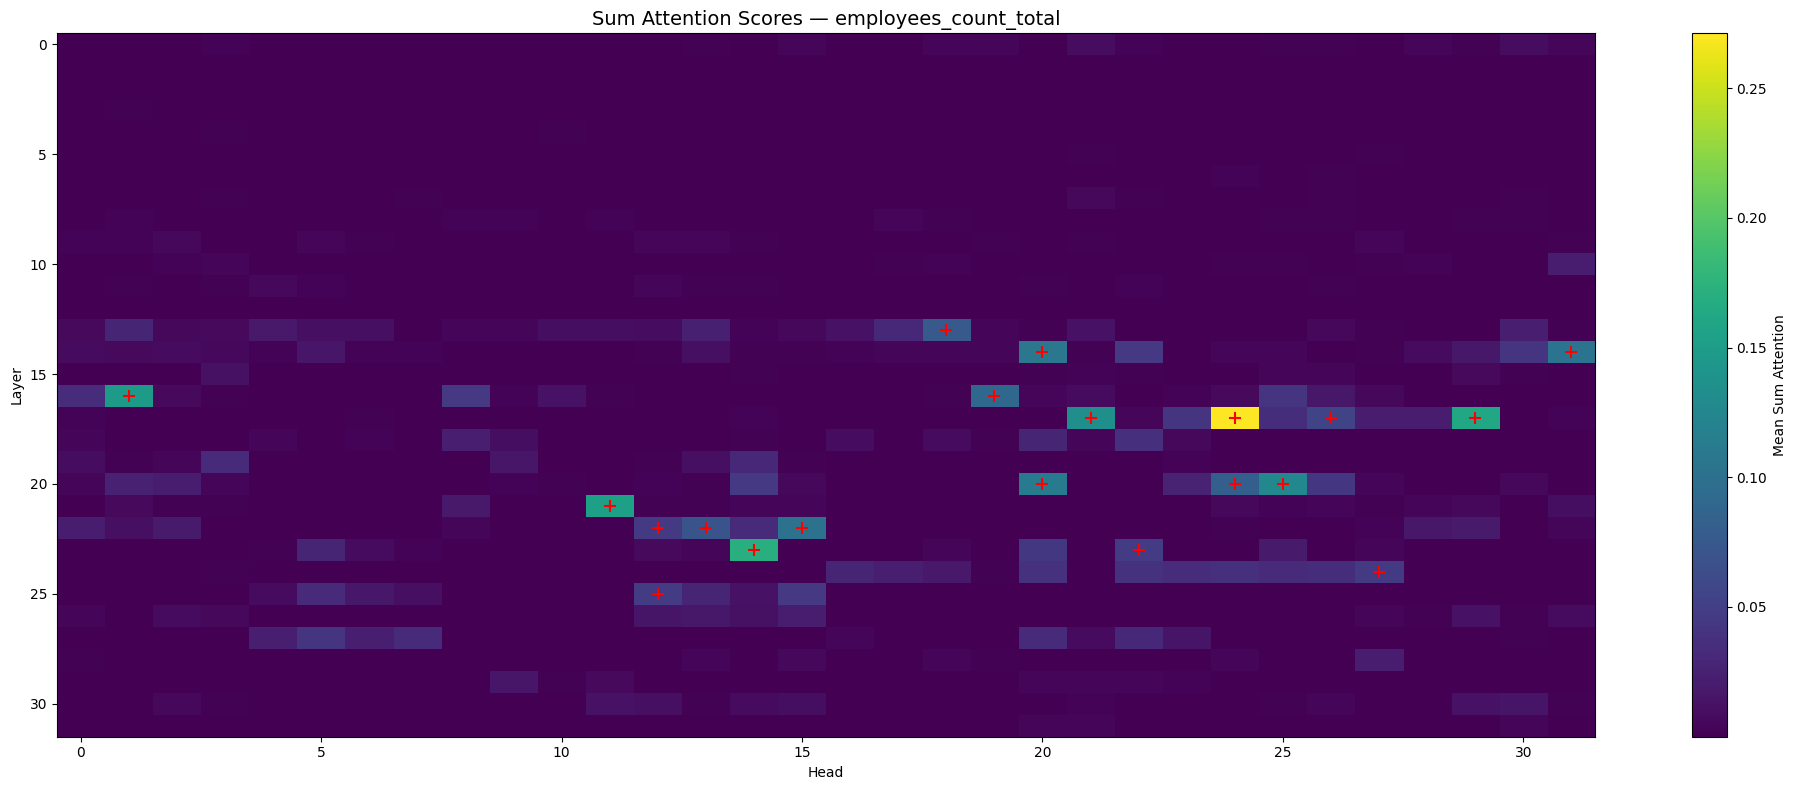

Saved at: content/data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50/results/heatmap_employees_count_total.png


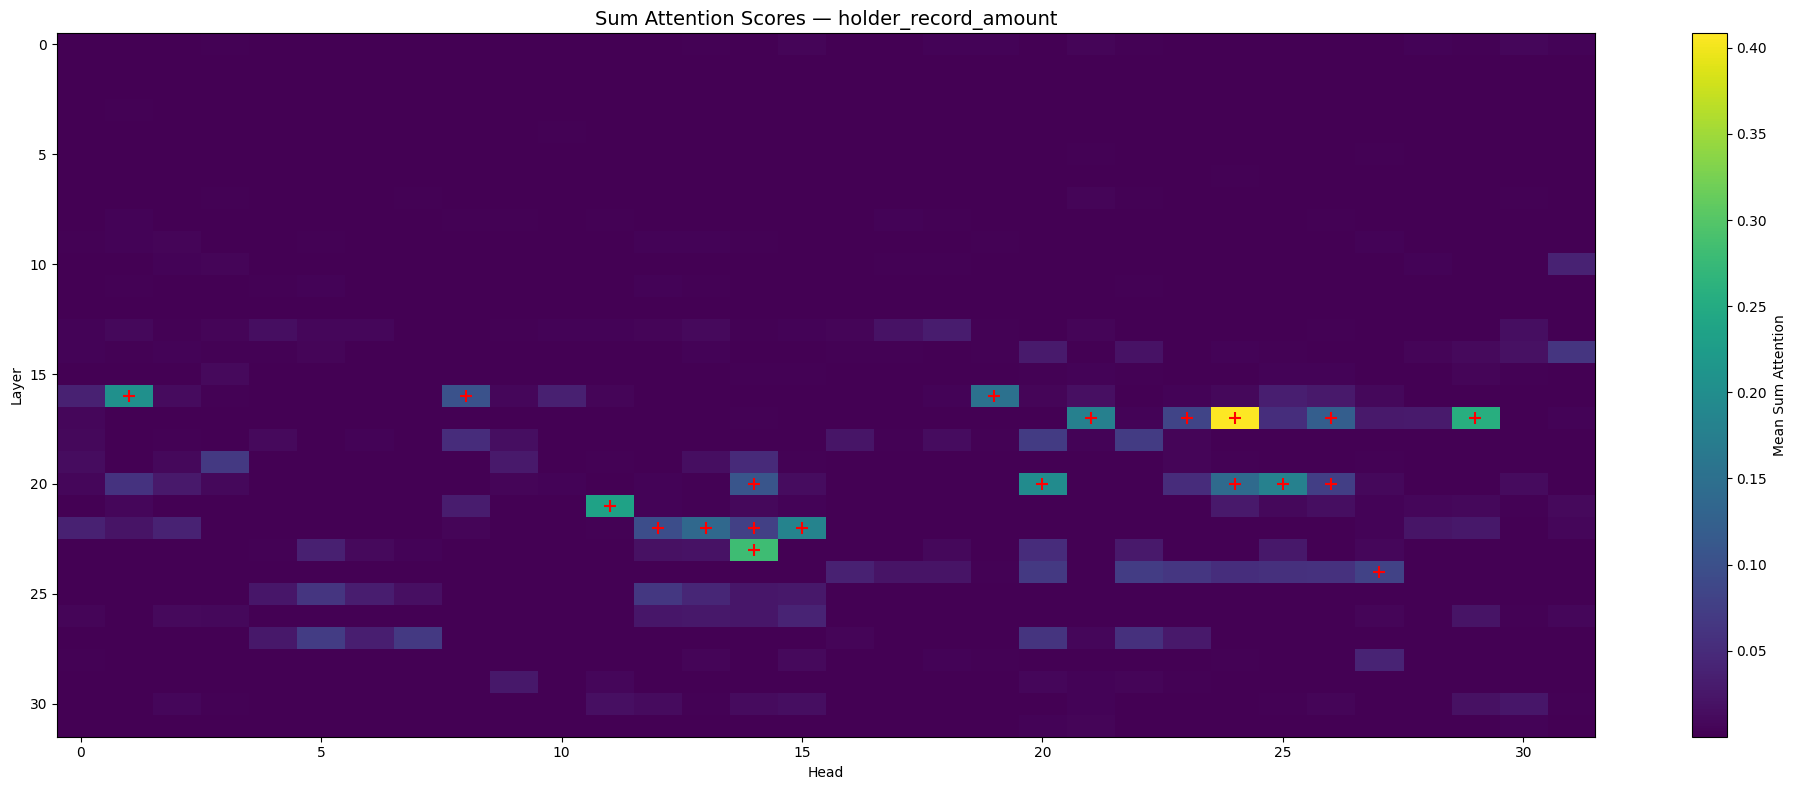

Saved at: content/data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50/results/heatmap_holder_record_amount.png


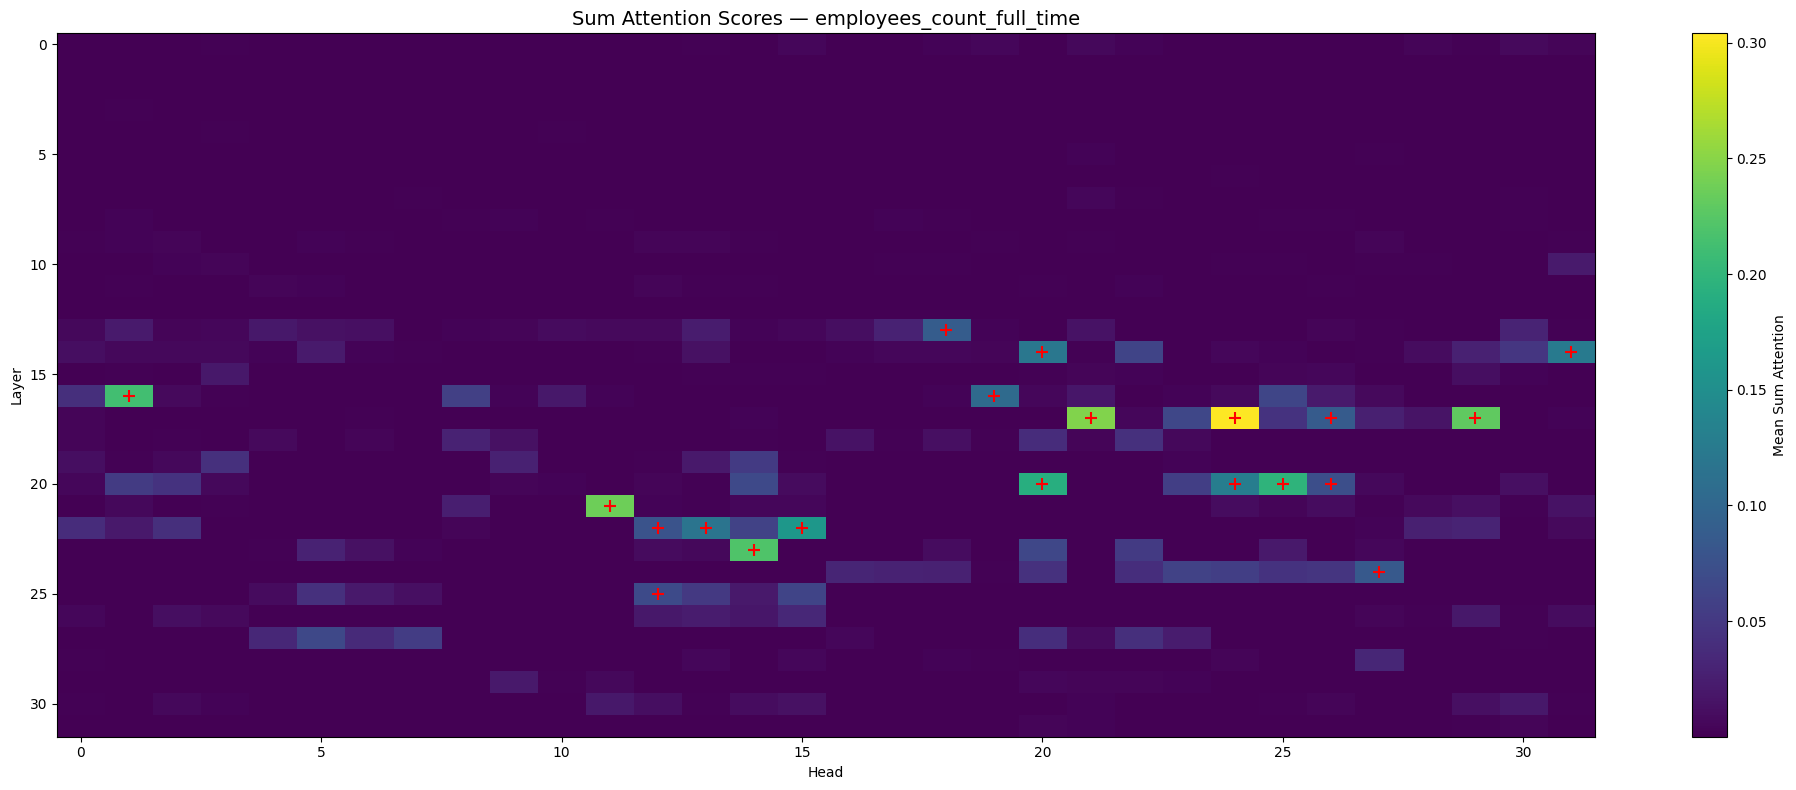

Saved at: content/data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50/results/heatmap_employees_count_full_time.png


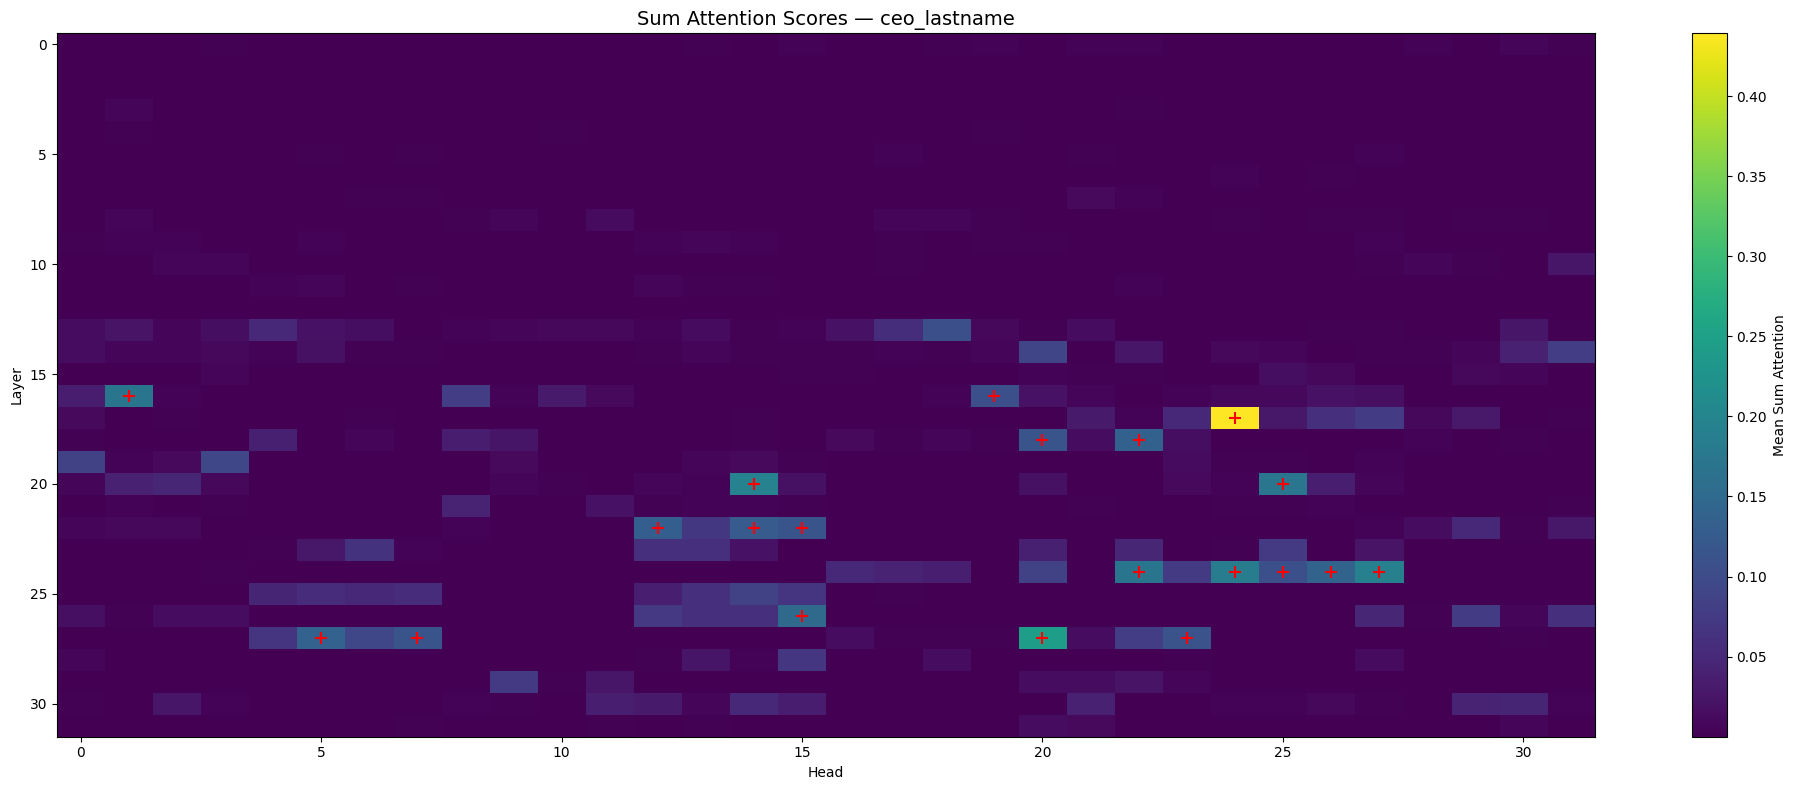

Saved at: content/data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50/results/heatmap_ceo_lastname.png


In [24]:
# Plot 1: Per-task heatmaps (layer × head mean score)
for task_id, mean_scores in task_mean_scores.items():
    fig, ax = plt.subplots(figsize=(20, 8))
    im = ax.imshow(mean_scores, aspect="auto", cmap="viridis")

    ax.set_title(f"Sum Attention Scores — {task_id}", fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
    plt.colorbar(im, ax=ax, label="Mean Sum Attention")

    for h in task_top_heads[task_id]:
        ax.plot(h["head"], h["layer"], "r+", markersize=8, markeredgewidth=1.5)

    plt.tight_layout()
    fig_path = os.path.join(RESULTS_OUTPUT_DIR, f"heatmap_{task_id}.png")
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print(f"Saved at: {fig_path}")

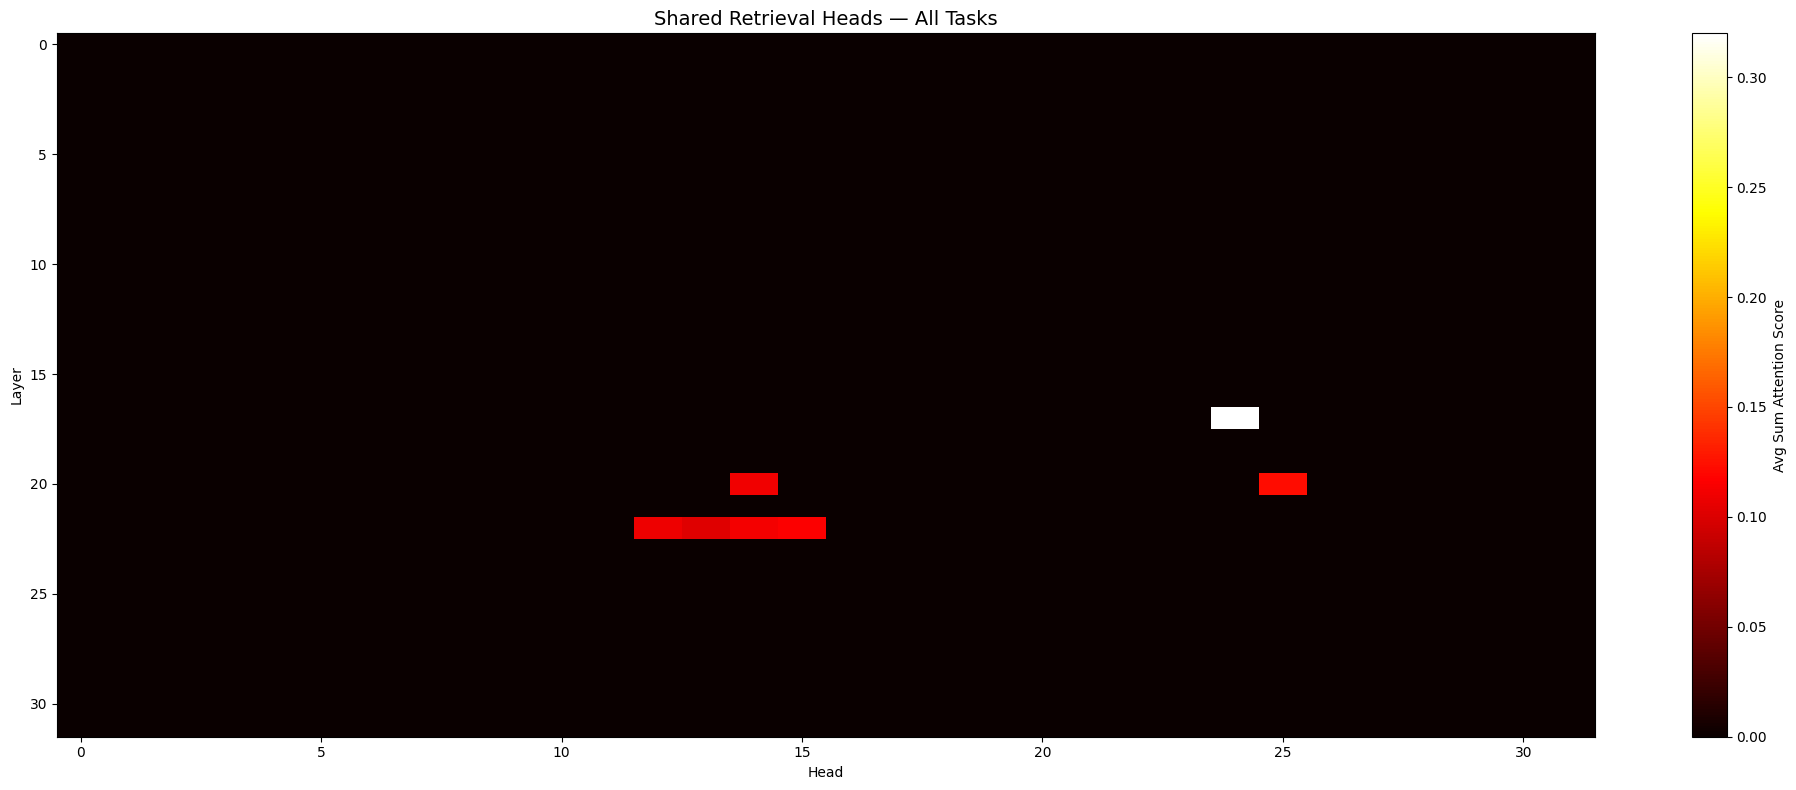

Saved at: content/data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50/results/shared_retrieval_heads.png


In [25]:
# Plot 2: Shared head distribution across layers
if shared_heads:
    layers = [h["layer"] for h in shared_heads]
    heads  = [h["head"]  for h in shared_heads]
    scores = [h["avg_score"] for h in shared_heads]

    num_layers = model.config.num_hidden_layers
    num_heads  = model.config.num_attention_heads
    grid = np.zeros((num_layers, num_heads))
    for h in shared_heads:
        grid[h["layer"], h["head"]] = h["avg_score"]

    fig, ax = plt.subplots(figsize=(20, 8))
    im = ax.imshow(grid, aspect="auto", cmap="hot")
    ax.set_title("Shared Retrieval Heads — All Tasks", fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
    plt.colorbar(im, ax=ax, label="Avg Sum Attention Score")

    plt.tight_layout()
    fig_path = os.path.join(RESULTS_OUTPUT_DIR, "shared_retrieval_heads.png")
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print(f"Saved at: {fig_path}")
else:
    print("No shared heads found across all tasks, consider relaxing TOP_K_HEADS.")

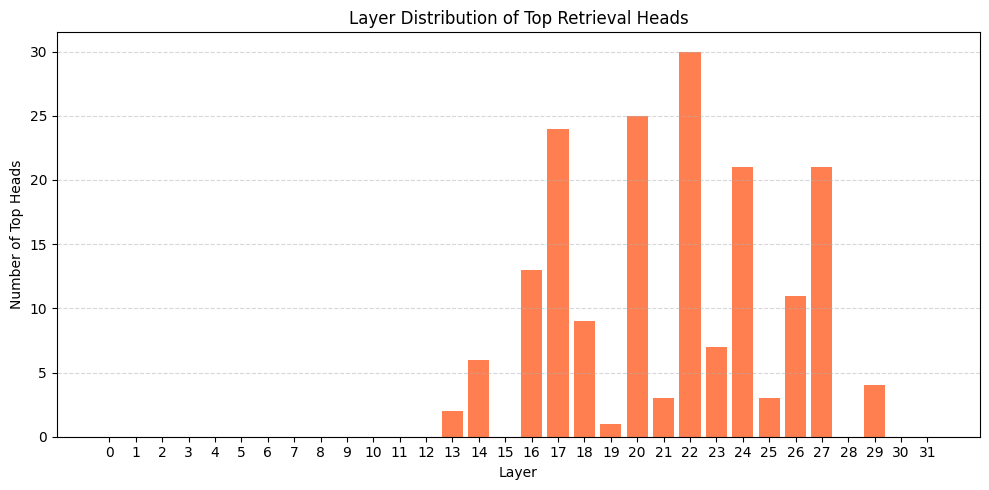

In [26]:
# Plot 3: Layer Distribution of top heads (for tasks)
num_layers = model.config.num_hidden_layers
layer_counts = np.zeros(num_layers)

for t_id, heads in task_top_heads.items():
    for h in heads:
        layer_counts[h["layer"]] += 1

plt.figure(figsize=(10, 5))
plt.bar(range(num_layers), layer_counts, color='coral')

plt.xlabel("Layer")
plt.ylabel("Number of Top Heads")
plt.title("Layer Distribution of Top Retrieval Heads")
plt.xticks(range(num_layers))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_OUTPUT_DIR, "layer_distribution.png"), dpi=150)
plt.show()

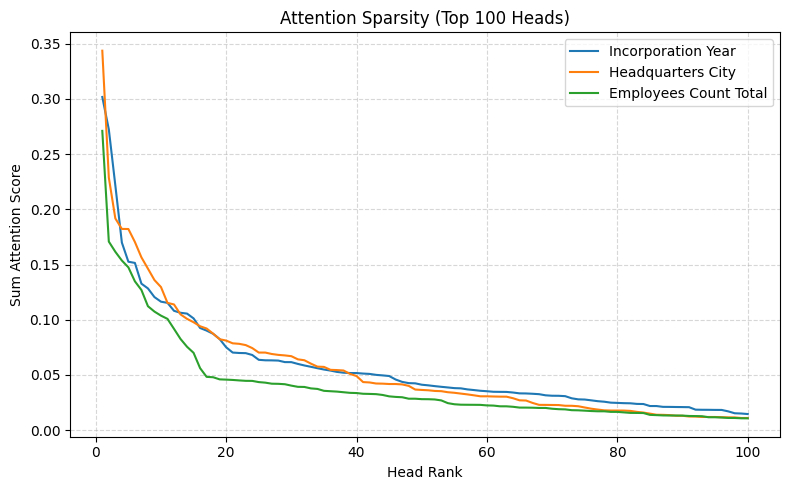

In [27]:
# Plot 4: Sparsity of attention scores for top heads across tasks (line plot of mean scores for top heads)
plt.figure(figsize=(8, 5))
tasks_to_plot = ['incorporation_year', 'headquarters_city', 'employees_count_total']

for t_id in tasks_to_plot:
    if t_id in task_mean_scores:
        scores = np.sort(task_mean_scores[t_id].flatten())[::-1]
        plt.plot(range(1, 101), scores[:100], label=t_id.replace('_', ' ').title())

plt.xlabel("Head Rank")
plt.ylabel("Sum Attention Score")
plt.title("Attention Sparsity (Top 100 Heads)")
plt.grid(linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_OUTPUT_DIR, "attention_sparsity.png"), dpi=150)
plt.show()

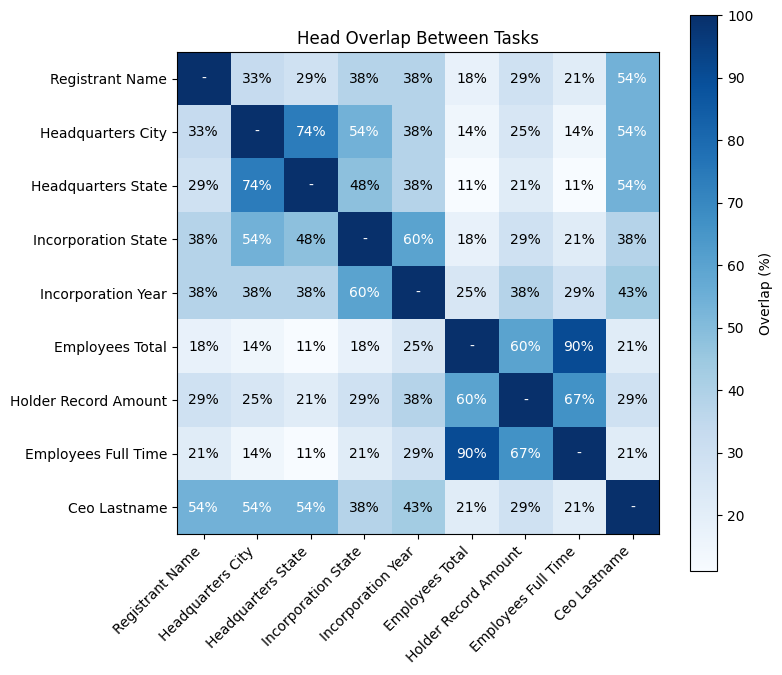

In [28]:
# Plot 5: Task Overlap Heatmap (Just curious to see if there are any clusters of tasks that have similar top heads)
task_ids = list(task_top_heads.keys())
n_tasks = len(task_ids)
overlap_matrix = np.zeros((n_tasks, n_tasks))

# Compute overlaps
for i, t1 in enumerate(task_ids):
    set1 = set((h["layer"], h["head"]) for h in task_top_heads[t1])
    for j, t2 in enumerate(task_ids):
        set2 = set((h["layer"], h["head"]) for h in task_top_heads[t2])
        union = len(set1 | set2)
        overlap_matrix[i, j] = (len(set1 & set2) / union * 100) if union > 0 else 0

clean_names = [t.replace('_', ' ').title().replace(' Count', '') for t in task_ids]

fig, ax = plt.subplots(figsize=(8, 7))
cax = ax.imshow(overlap_matrix, cmap='Blues')
plt.colorbar(cax, label='Overlap (%)')

ax.set_xticks(np.arange(n_tasks))
ax.set_yticks(np.arange(n_tasks))
ax.set_xticklabels(clean_names, rotation=45, ha='right')
ax.set_yticklabels(clean_names)

for i in range(n_tasks):
    for j in range(n_tasks):
        val = overlap_matrix[i, j]
        color = 'white' if val > 50 else 'black'
        text = f"{val:.0f}%" if i != j else "-"
        ax.text(j, i, text, ha='center', va='center', color=color)

plt.title("Head Overlap Between Tasks")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_OUTPUT_DIR, "task_overlap_heatmap.png"), dpi=150)
plt.show()

In [29]:
import shutil
from google.colab import files

# Define the folder path and the output zip file name
folder_path = '/content/content/data/retrieval_heads'
output_filename = '/content/retrieval_heads_results.zip'

# Create a zip file of the folder
shutil.make_archive(output_filename.replace('.zip', ''), 'zip', folder_path)

print(f"Zipped folder to {output_filename}")

# Trigger the download
files.download(output_filename)

Zipped folder to /content/retrieval_heads_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>